In [1]:
import warnings
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')

data_path = Path('/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v5/wgs.auto.par/results/16_cov_pheno_prep')

# 1) sex + pc (pc from BBJ projection)
cov_bbj_sex_pc = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.cov.sex.tsv', sep='\t')

# 2) sex + pc (pc from our genotype)
cov_genotype_sex_pc = pd.read_csv(data_path / 'popgmm_relatedness_aware_projection.cov.sex.tsv', sep='\t')

# 3) sex + age + pc (pc from BBJ projection)
cov_bbj_sex_age_pc = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.cov.sex_age_agez.tsv', sep='\t')

# 4) sex + age + pc (pc from our genotype)
cov_genotype_sex_age_pc = pd.read_csv(data_path / 'popgmm_relatedness_aware_projection.cov.sex_age_agez.tsv', sep='\t')

# 5) phenotype
pheno = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.pheno.tsv', sep='\t')

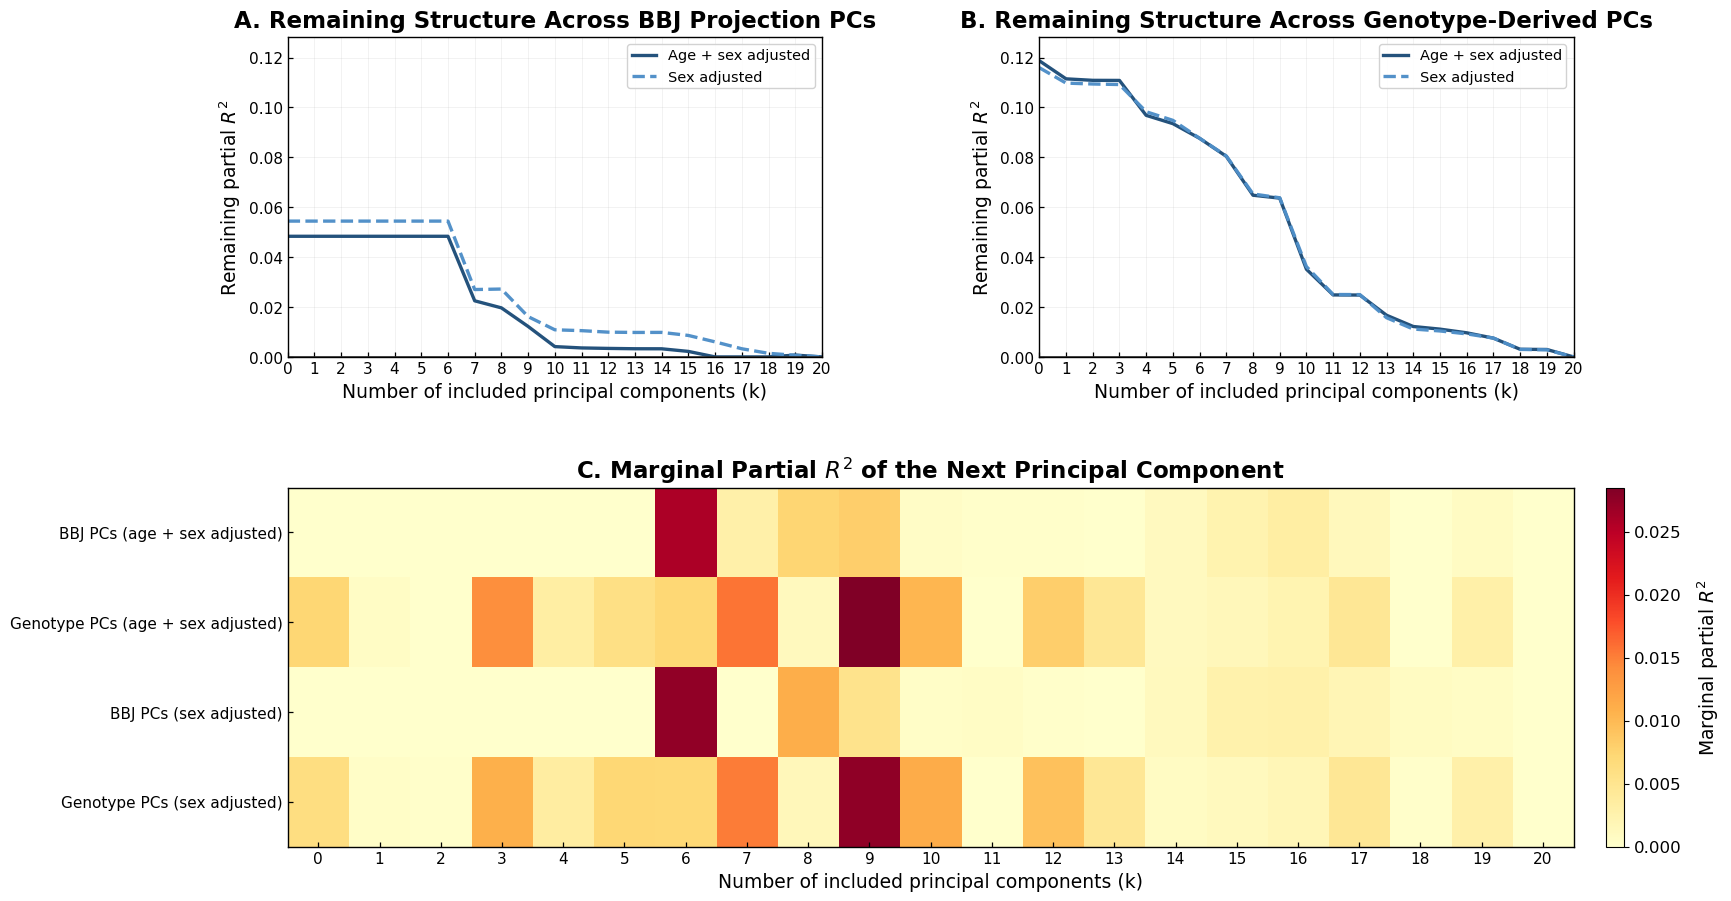

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

warnings.filterwarnings('ignore', message='Setting penalty=None will ignore the C and l1_ratio parameters')

ID_COLS = ['#FID', 'IID']
PHENO_COL = 'PHENO1'
SEX_COL = 'SEX'
AGE_COL = 'AGE_Z'
MAX_PC = 20

def merge_cov_pheno(cov_df, pheno_df):
    return cov_df.merge(pheno_df[ID_COLS + [PHENO_COL]], on=ID_COLS, how='inner').copy()

def detect_and_encode_pheno(y):
    y = pd.Series(y).copy()
    y = y[~y.isna()]
    uniq = sorted(y.unique().tolist())

    if set(uniq).issubset({-9, 0, 1, 2}):
        y2 = pd.Series(y).replace(-9, np.nan).dropna()
        u2 = set(y2.unique().tolist())
        if u2.issubset({1, 2}):
            return 'binary', (y2 == 2).astype(int)
        if u2.issubset({0, 1}):
            return 'binary', y2.astype(int)

    if len(uniq) <= 2:
        mapper = {v: i for i, v in enumerate(uniq)}
        return 'binary', pd.Series(y).map(mapper).astype(int)

    return 'continuous', y.astype(float)

def fit_model(df, covariates):
    d = df[covariates + [PHENO_COL]].dropna().copy()
    if d.empty:
        return np.nan

    mode, y = detect_and_encode_pheno(d[PHENO_COL])

    if mode == 'binary':
        d = d.loc[y.index].copy()
        X = d[covariates].astype(float).to_numpy()
        yv = y.astype(float).to_numpy()
        model = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
        model.fit(X, yv.astype(int))
        p = model.predict_proba(X)[:, 1]
        p = np.clip(p, 1e-12, 1 - 1e-12)
        one_minus_y = np.subtract(1.0, yv)
        one_minus_p = np.subtract(1.0, p)
        ll = np.sum(yv * np.log(p) + one_minus_y * np.log(one_minus_p))
        p0 = np.clip(np.mean(yv), 1e-12, 1 - 1e-12)
        ll0 = np.sum(yv * np.log(p0) + one_minus_y * np.log(np.subtract(1.0, p0)))
        return 1 - (ll / ll0)

    X = d[covariates].astype(float).values
    yv = d[PHENO_COL].astype(float).values
    model = LinearRegression()
    model.fit(X, yv)
    return model.score(X, yv)

def get_pc_cols(df):
    cols = [c for c in df.columns if c.startswith('PC') and c.endswith('_AVG')]
    return sorted(cols, key=lambda x: int(x.split('_')[0].replace('PC', '')))

def build_curve(df, base_covariates, max_pc=20):
    pcs = get_pc_cols(df)
    max_k = min(max_pc, len(pcs))
    r2_by_k = []
    for k in range(max_k + 1):
        r2_by_k.append(fit_model(df, base_covariates + pcs[:k]))
    out = pd.DataFrame({'k_included': list(range(max_k + 1)), 'r2': r2_by_k})
    out['cum_gain'] = out['r2'] - out.loc[0, 'r2']
    out['step_gain'] = out['r2'].diff()
    return out

def residual_structure_metrics(curve_df):
    g = curve_df.sort_values('k_included').reset_index(drop=True).copy()
    max_k = int(g['k_included'].max())
    full_gain = g.loc[g['k_included'] == max_k, 'cum_gain'].values[0]
    rows = []
    for k in range(max_k + 1):
        joint_remaining = full_gain - g.loc[g['k_included'] == k, 'cum_gain'].values[0]
        if k < max_k:
            next_pc_partial = g.loc[g['k_included'] == (k + 1), 'step_gain'].values[0]
        else:
            next_pc_partial = np.nan
        rows.append({
            'k_included': k,
            'joint_remaining_partial_r2': joint_remaining,
            'next_pc_partial_r2': next_pc_partial,
        })
    return pd.DataFrame(rows)

settings = {
    'with_age': {
        'data_map': {
            'bbj': merge_cov_pheno(cov_bbj_sex_age_pc, pheno),
            'genotype': merge_cov_pheno(cov_genotype_sex_age_pc, pheno),
        },
        'base_cov': [SEX_COL, AGE_COL],
    },
    'no_age': {
        'data_map': {
            'bbj': merge_cov_pheno(cov_bbj_sex_pc, pheno),
            'genotype': merge_cov_pheno(cov_genotype_sex_pc, pheno),
        },
        'base_cov': [SEX_COL],
    },
}

all_metrics = {}
for setting_name, cfg in settings.items():
    curves = {src: build_curve(df, cfg['base_cov'], MAX_PC) for src, df in cfg['data_map'].items()}
    all_metrics[setting_name] = {src: residual_structure_metrics(curve) for src, curve in curves.items()}

rows = []
for setting_name in ['with_age', 'no_age']:
    for src in ['bbj', 'genotype']:
        m = all_metrics[setting_name][src].copy()
        m['setting'] = setting_name
        m['source'] = src
        rows.append(m)
diag = pd.concat(rows, ignore_index=True)
diag = diag.sort_values(['setting', 'source', 'k_included']).reset_index(drop=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'axes.titlesize': 16.5,
    'axes.labelsize': 13.5,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10.5,
    'axes.linewidth': 1.0,
    'axes.spines.top': True,
    'axes.spines.right': True,
})

y_vals = []
for src in ['bbj', 'genotype']:
    for setting_name in ['with_age', 'no_age']:
        g = diag[(diag['source'] == src) & (diag['setting'] == setting_name)]
        y_vals.extend(np.maximum(g['joint_remaining_partial_r2'].dropna().values, 0).tolist())
y_min = min(y_vals)
y_max = max(y_vals)
y_pad = (y_max - y_min) * 0.08 if y_max > y_min else 0.01
y_lim = (max(0, y_min - y_pad), y_max + y_pad)

fig = plt.figure(figsize=(17.2, 8.9), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[0.98, 1.10], hspace=0.12, wspace=0.08)

line_colors = {'with_age': '#1f4e79', 'no_age': '#4f8fc8'}
line_styles = {'with_age': '-', 'no_age': '--'}
line_labels = {'with_age': 'Age + sex adjusted', 'no_age': 'Sex adjusted'}
titles = {'bbj': 'A. Remaining Structure Across BBJ Projection PCs', 'genotype': 'B. Remaining Structure Across Genotype-Derived PCs'}

axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
for col_i, src in enumerate(['bbj', 'genotype']):
    ax = axes[col_i]
    for setting_name in ['with_age', 'no_age']:
        g = diag[(diag['source'] == src) & (diag['setting'] == setting_name)].copy()
        g = g.sort_values('k_included')
        g['joint_remaining_plot'] = np.maximum(g['joint_remaining_partial_r2'], 0)
        ax.plot(
            g['k_included'], g['joint_remaining_plot'],
            linestyle=line_styles[setting_name],
            color=line_colors[setting_name],
            linewidth=2.4,
            alpha=0.98,
            label=line_labels[setting_name]
        )
    ax.axhline(0, color='#333333', linewidth=1.2)
    ax.set_title(titles[src], pad=7, fontweight='semibold')
    ax.set_xlabel('Number of included principal components (k)', labelpad=4)
    ax.set_ylabel('Remaining partial $R^2$', labelpad=4)
    ax.set_xlim(0, MAX_PC)
    ax.set_xticks(np.arange(0, MAX_PC + 1, 1))
    ax.set_ylim(y_lim)
    ax.grid(alpha=0.18, linestyle='-', linewidth=0.6)
    ax.legend(loc='upper right', frameon=True, framealpha=0.92, edgecolor='#cfcfcf', borderpad=0.30, handlelength=1.7)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
    ax.tick_params(direction='in', length=3.5, width=0.9, top=False, right=False)

ax3 = fig.add_subplot(gs[1, :])
order_rows = [('with_age', 'bbj'), ('with_age', 'genotype'), ('no_age', 'bbj'), ('no_age', 'genotype')]
mat = []
row_labels = []
for setting_name, src in order_rows:
    g = diag[(diag['setting'] == setting_name) & (diag['source'] == src)].sort_values('k_included')
    v = np.maximum(g['next_pc_partial_r2'].fillna(0).values, 0)
    if len(v) < MAX_PC + 1:
        v = np.pad(v, (0, MAX_PC + 1 - len(v)), mode='constant', constant_values=0)
    else:
        v = v[:MAX_PC + 1]
    mat.append(v)
    src_label = 'BBJ PCs' if src == 'bbj' else 'Genotype PCs'
    adjust_label = 'age + sex adjusted' if setting_name == 'with_age' else 'sex adjusted'
    row_labels.append(f'{src_label} ({adjust_label})')
mat = np.array(mat)

im = ax3.imshow(mat, aspect='auto', cmap='YlOrRd', interpolation='nearest', vmin=0, vmax=np.nanmax(mat))
ax3.set_title('C. Marginal Partial $R^2$ of the Next Principal Component', pad=7, fontweight='semibold')
ax3.set_xlabel('Number of included principal components (k)', labelpad=4)
ax3.set_yticks(np.arange(len(row_labels)))
ax3.set_yticklabels(row_labels)
ax3.set_xlim(-0.5, MAX_PC + 0.5)
ax3.set_xticks(np.arange(0, MAX_PC + 1, 1))
for spine in ax3.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
ax3.tick_params(direction='in', length=3.5, width=0.9, top=False, right=False)

cbar = plt.colorbar(im, ax=ax3, fraction=0.026, pad=0.018)
cbar.set_label('Marginal partial $R^2$', rotation=90, labelpad=10)
cbar.outline.set_linewidth(0.8)
cbar.ax.tick_params(labelsize=12)

plt.show()

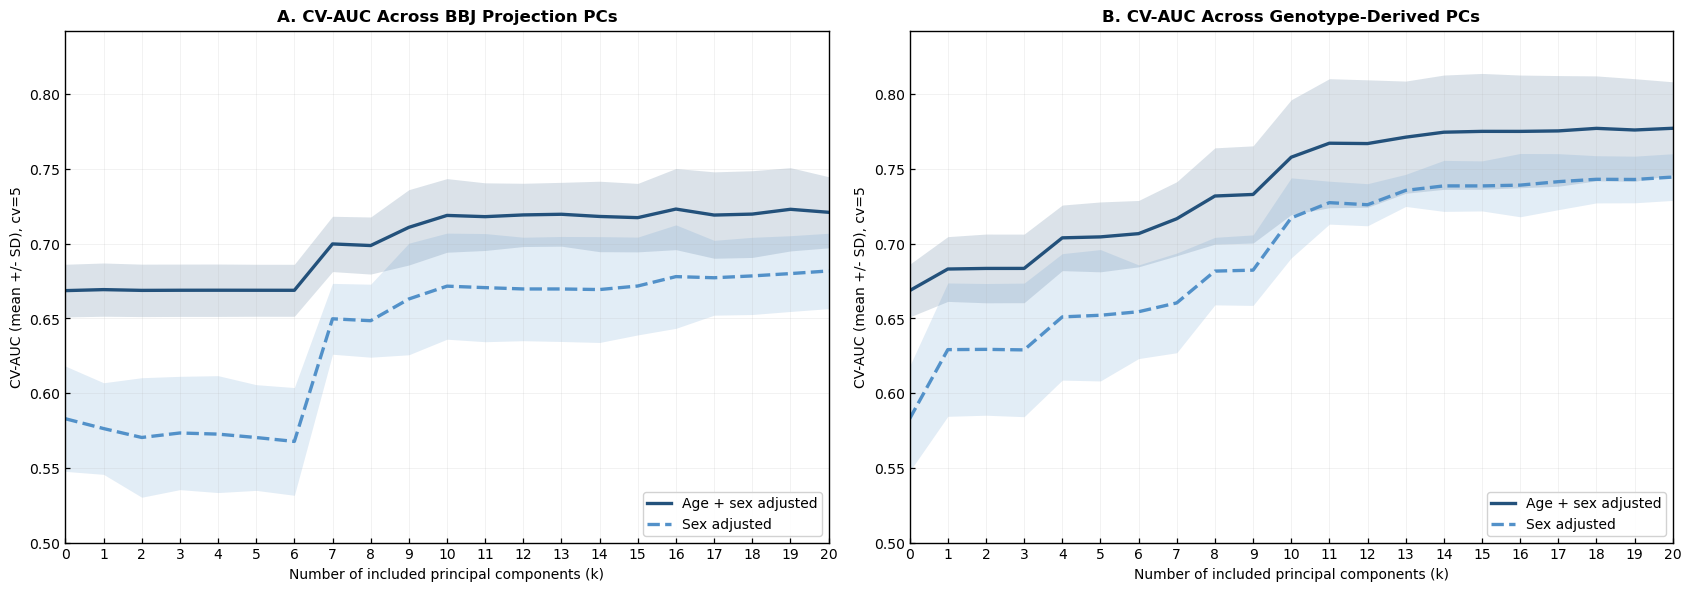

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

ID_COLS = ['#FID', 'IID']
PHENO_COL = 'PHENO1'
SEX_COL = 'SEX'
AGE_COL = 'AGE_Z'
MAX_PC = 20
CV_FOLDS = 5
N_JOBS = 3  # default multi-core parallelism

def encode_binary_pheno(y):
    y = pd.Series(y).copy()
    y = y.replace(-9, np.nan).dropna()
    uniq = sorted(y.unique().tolist())

    if set(uniq).issubset({1, 2}):
        return (y == 2).astype(int)
    if set(uniq).issubset({0, 1}):
        return y.astype(int)
    if len(uniq) == 2:
        mapper = {v: i for i, v in enumerate(uniq)}
        return y.map(mapper).astype(int)

    raise ValueError(f'PHENO1 is not binary. Unique values after cleanup: {uniq}')

def get_pc_cols(df):
    cols = [c for c in df.columns if c.startswith('PC') and c.endswith('_AVG')]
    return sorted(cols, key=lambda x: int(x.split('_')[0].replace('PC', '')))

def compute_cv_auc(X, y, cv_folds=5, n_jobs=3):
    y = pd.Series(y).astype(int)
    class_counts = y.value_counts()
    min_class_n = int(class_counts.min()) if not class_counts.empty else 0
    effective_cv = min(cv_folds, min_class_n)

    if y.nunique() < 2 or effective_cv < 2:
        return np.nan, np.nan, effective_cv

    cv = StratifiedKFold(n_splits=effective_cv, shuffle=True, random_state=42)
    model = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
    scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=n_jobs)
    return float(np.mean(scores)), float(np.std(scores, ddof=1)), effective_cv

def build_auc_curve_cv(cov_df, pheno_df, base_covariates, max_pc=20, cv_folds=5, n_jobs=3):
    d = cov_df.merge(pheno_df[ID_COLS + [PHENO_COL]], on=ID_COLS, how='inner').copy()
    pcs = get_pc_cols(d)
    max_k = min(max_pc, len(pcs))

    rows = []
    for k in range(max_k + 1):
        covs = base_covariates + pcs[:k]
        tmp = d[covs + [PHENO_COL]].dropna().copy()
        if tmp.empty:
            rows.append({'k_included': k, 'auc_mean': np.nan, 'auc_std': np.nan, 'effective_cv': 0})
            continue

        y = encode_binary_pheno(tmp[PHENO_COL])
        tmp = tmp.loc[y.index].copy()
        if tmp.empty or y.nunique() < 2:
            rows.append({'k_included': k, 'auc_mean': np.nan, 'auc_std': np.nan, 'effective_cv': 0})
            continue

        X = tmp[covs].astype(float).to_numpy()
        yv = y.astype(int).to_numpy()
        auc_mean, auc_std, eff_cv = compute_cv_auc(X, yv, cv_folds=cv_folds, n_jobs=n_jobs)
        rows.append({'k_included': k, 'auc_mean': auc_mean, 'auc_std': auc_std, 'effective_cv': eff_cv})

    out = pd.DataFrame(rows)
    out['auc_mean'] = pd.to_numeric(out['auc_mean'], errors='coerce')
    out['auc_std'] = pd.to_numeric(out['auc_std'], errors='coerce')
    baseline_auc = float(out.loc[0, 'auc_mean']) if pd.notna(out.loc[0, 'auc_mean']) else np.nan
    out['cum_gain_auc'] = out['auc_mean'] - baseline_auc
    out['step_gain_auc'] = out['auc_mean'].diff()
    out['auc_mean_minus_std'] = out['auc_mean'] - out['auc_std']
    out['auc_mean_plus_std'] = out['auc_mean'] + out['auc_std']
    out['auc_mean_pm_std'] = out['auc_mean'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan') + ' +/- ' + out['auc_std'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')
    return out

auc_settings = {
    'with_age': {
        'data_map': {
            'bbj': cov_bbj_sex_age_pc,
            'genotype': cov_genotype_sex_age_pc,
        },
        'base_cov': [SEX_COL, AGE_COL],
    },
    'no_age': {
        'data_map': {
            'bbj': cov_bbj_sex_pc,
            'genotype': cov_genotype_sex_pc,
        },
        'base_cov': [SEX_COL],
    },
}

auc_curves = {}
for setting_name, cfg in auc_settings.items():
    auc_curves[setting_name] = {}
    for src, cov_df in cfg['data_map'].items():
        auc_curves[setting_name][src] = build_auc_curve_cv(
            cov_df=cov_df,
            pheno_df=pheno,
            base_covariates=cfg['base_cov'],
            max_pc=MAX_PC,
            cv_folds=CV_FOLDS,
            n_jobs=N_JOBS,
        )

plot_rows = []
for setting_name in ['with_age', 'no_age']:
    for src in ['bbj', 'genotype']:
        g = auc_curves[setting_name][src].copy()
        g['setting'] = setting_name
        g['source'] = src
        plot_rows.append(g)
auc_diag = pd.concat(plot_rows, ignore_index=True)

line_colors = {'with_age': '#1f4e79', 'no_age': '#4f8fc8'}
line_styles = {'with_age': '-', 'no_age': '--'}
line_labels = {'with_age': 'Age + sex adjusted', 'no_age': 'Sex adjusted'}
titles = {
    'bbj': 'A. CV-AUC Across BBJ Projection PCs',
    'genotype': 'B. CV-AUC Across Genotype-Derived PCs',
}

all_low = auc_diag['auc_mean_minus_std'].dropna().values
all_high = auc_diag['auc_mean_plus_std'].dropna().values
y_min = np.nanmin(all_low)
y_max = np.nanmax(all_high)
y_pad = (y_max - y_min) * 0.10 if y_max > y_min else 0.01

fig, axes = plt.subplots(1, 2, figsize=(16.8, 5.8), constrained_layout=True)
for i, src in enumerate(['bbj', 'genotype']):
    ax = axes[i]
    for setting_name in ['with_age', 'no_age']:
        g = auc_diag[(auc_diag['source'] == src) & (auc_diag['setting'] == setting_name)].sort_values('k_included')
        x = g['k_included'].to_numpy()
        y = g['auc_mean'].to_numpy()
        y_lo = g['auc_mean_minus_std'].to_numpy()
        y_hi = g['auc_mean_plus_std'].to_numpy()
        ax.plot(
            x, y,
            linestyle=line_styles[setting_name],
            color=line_colors[setting_name],
            linewidth=2.4,
            alpha=0.98,
            label=line_labels[setting_name],
        )
        ax.fill_between(x, y_lo, y_hi, color=line_colors[setting_name], alpha=0.16, linewidth=0)
    ax.set_title(titles[src], pad=7, fontweight='semibold')
    ax.set_xlabel('Number of included principal components (k)', labelpad=4)
    ax.set_ylabel(f'CV-AUC (mean +/- SD), cv={CV_FOLDS}', labelpad=4)
    ax.set_xlim(0, MAX_PC)
    ax.set_xticks(np.arange(0, MAX_PC + 1, 1))
    ax.set_ylim(0.5, y_max + y_pad)
    ax.grid(alpha=0.18, linestyle='-', linewidth=0.6)
    ax.legend(loc='lower right', frameon=True, framealpha=0.92, edgecolor='#cfcfcf', borderpad=0.30, handlelength=1.7)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
    ax.tick_params(direction='in', length=3.5, width=0.9, top=False, right=False)

plt.show()

# contrib_cv = auc_diag[
#     ['setting', 'source', 'k_included', 'effective_cv', 'auc_mean', 'auc_std', 'auc_mean_pm_std', 'cum_gain_auc', 'step_gain_auc']
# ].copy()
# contrib_cv = contrib_cv.sort_values(['setting', 'source', 'k_included']).reset_index(drop=True)
# display(contrib_cv)